In [16]:
"Benjamin Naranjo"
"21687575-3"
"06/05/26"

'06/05/26'

In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(
    style='whitegrid',
    palette='muted',
    font_scale=1.2
)
df = pd.read_csv('cafeteria_universitaria_s8.csv')


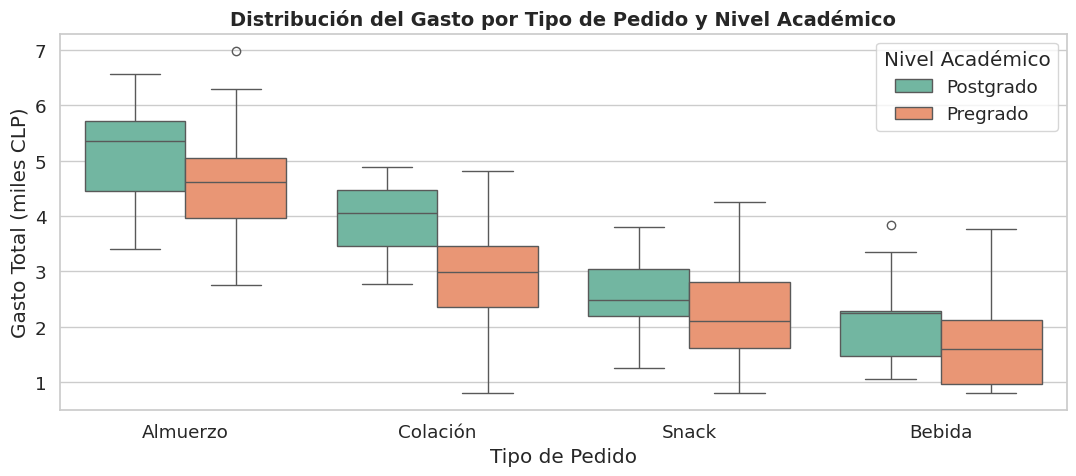

In [18]:
fig, ax = plt.subplots(figsize=(11, 5))

sns.boxplot(
    data=df,
    x='tipo_pedido',
    y='gasto_total',
    hue='nivel_academico',
    palette='Set2',
    order=['Almuerzo', 'Colación', 'Snack', 'Bebida'],
)

ax.set_title('Distribución del Gasto por Tipo de Pedido y Nivel Académico',fontsize=14, fontweight='bold')
ax.set_xlabel('Tipo de Pedido')
ax.set_ylabel('Gasto Total (miles CLP)')
ax.legend(title='Nivel Académico', loc='upper right')

plt.tight_layout()
plt.show() # Reemplazo de plt.***()

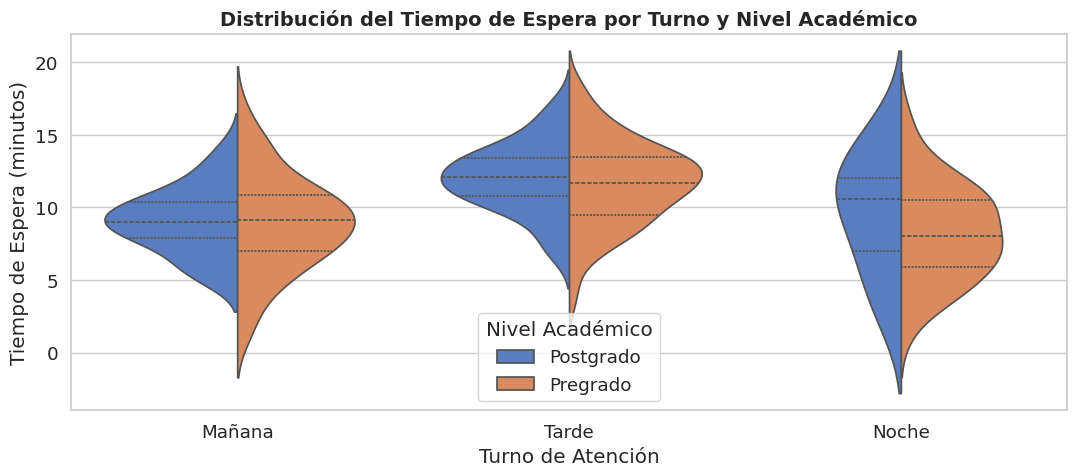

In [19]:
fig, ax = plt.subplots(figsize=(11, 5))

sns.violinplot(
    data=df,
    x='turno',
    y='tiempo_espera_min',
    hue='nivel_academico',
    split=True,
    inner='quartile',
    palette='muted',
    order=['Mañana', 'Tarde', 'Noche'],
    ax=ax
)
ax.set_title('Distribución del Tiempo de Espera por Turno y Nivel Académico',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Turno de Atención')
ax.set_ylabel('Tiempo de Espera (minutos)')
ax.legend(title='Nivel Académico')

plt.tight_layout()
plt.show()

Variables numéricas: ['semana_mes', 'gasto_total', 'tiempo_espera_min', 'calificacion_servicio', 'items_pedido', 'propina_porcentaje']

Matriz de correlación:
                       semana_mes  gasto_total  tiempo_espera_min  \
semana_mes                   1.00        -0.03              -0.07   
gasto_total                 -0.03         1.00               0.49   
tiempo_espera_min           -0.07         0.49               1.00   
calificacion_servicio        0.07        -0.16              -0.24   
items_pedido                -0.08         0.30               0.15   
propina_porcentaje           0.00         0.02              -0.04   

                       calificacion_servicio  items_pedido  propina_porcentaje  
semana_mes                              0.07         -0.08                0.00  
gasto_total                            -0.16          0.30                0.02  
tiempo_espera_min                      -0.24          0.15               -0.04  
calificacion_servicio            

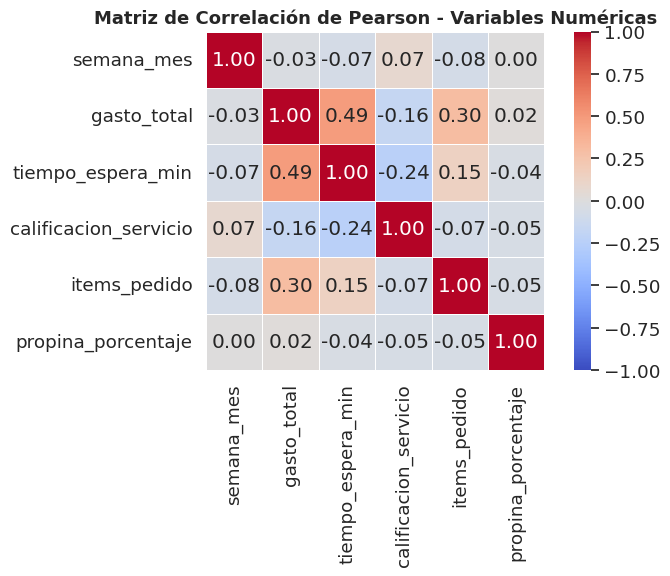

In [20]:
num_cols = df.select_dtypes(include=[np.number])
print('Variables numéricas:', list(num_cols.columns))

corr_matrix = num_cols.corr()
print('\nMatriz de correlación:')
print(corr_matrix.round(2))

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    data=corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor='white',
    square=True,
    ax=ax
)

ax.set_title('Matriz de Correlación de Pearson - Variables Numéricas',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

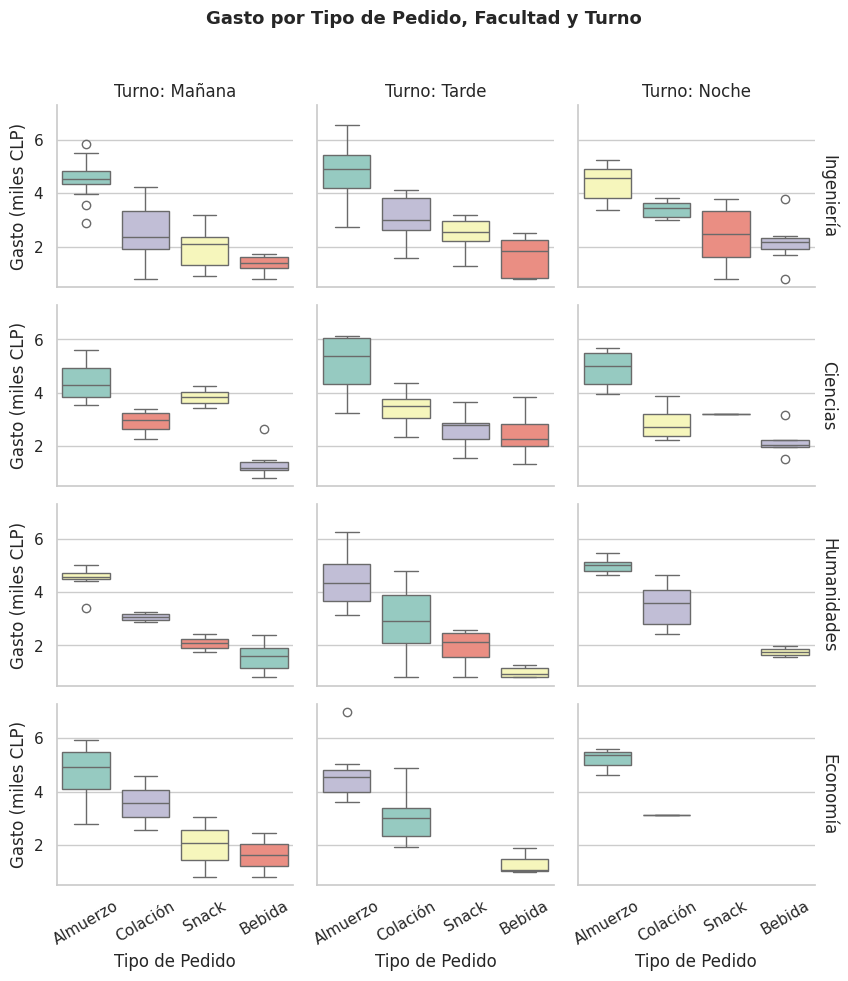

In [23]:
sns.set_theme(style='whitegrid', font_scale=1.0)

g = sns.FacetGrid(
    df,
    col='turno',
    row='facultad',
    col_order=['Mañana', 'Tarde', 'Noche'],
    row_order=['Ingeniería', 'Ciencias', 'Humanidades', 'Economía'],
    height=2.4,
    aspect=1.2,
    margin_titles=True
)

g.map_dataframe(
    sns.boxplot,
    x='tipo_pedido',
    y='gasto_total',
    hue='tipo_pedido',
    palette='Set3',
    order=['Almuerzo', 'Colación', 'Snack', 'Bebida'],
    legend=False
)

g.set_axis_labels('Tipo de Pedido', 'Gasto (miles CLP)')
g.set_titles(col_template='Turno: {col_name}', row_template='{row_name}')

g.figure.suptitle(
    'Gasto por Tipo de Pedido, Facultad y Turno',
    y=1.02, fontsize=13, fontweight='bold'
)

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
g.savefig('act4_facetgrid.png', dpi=300, bbox_inches='tight')
plt.show()

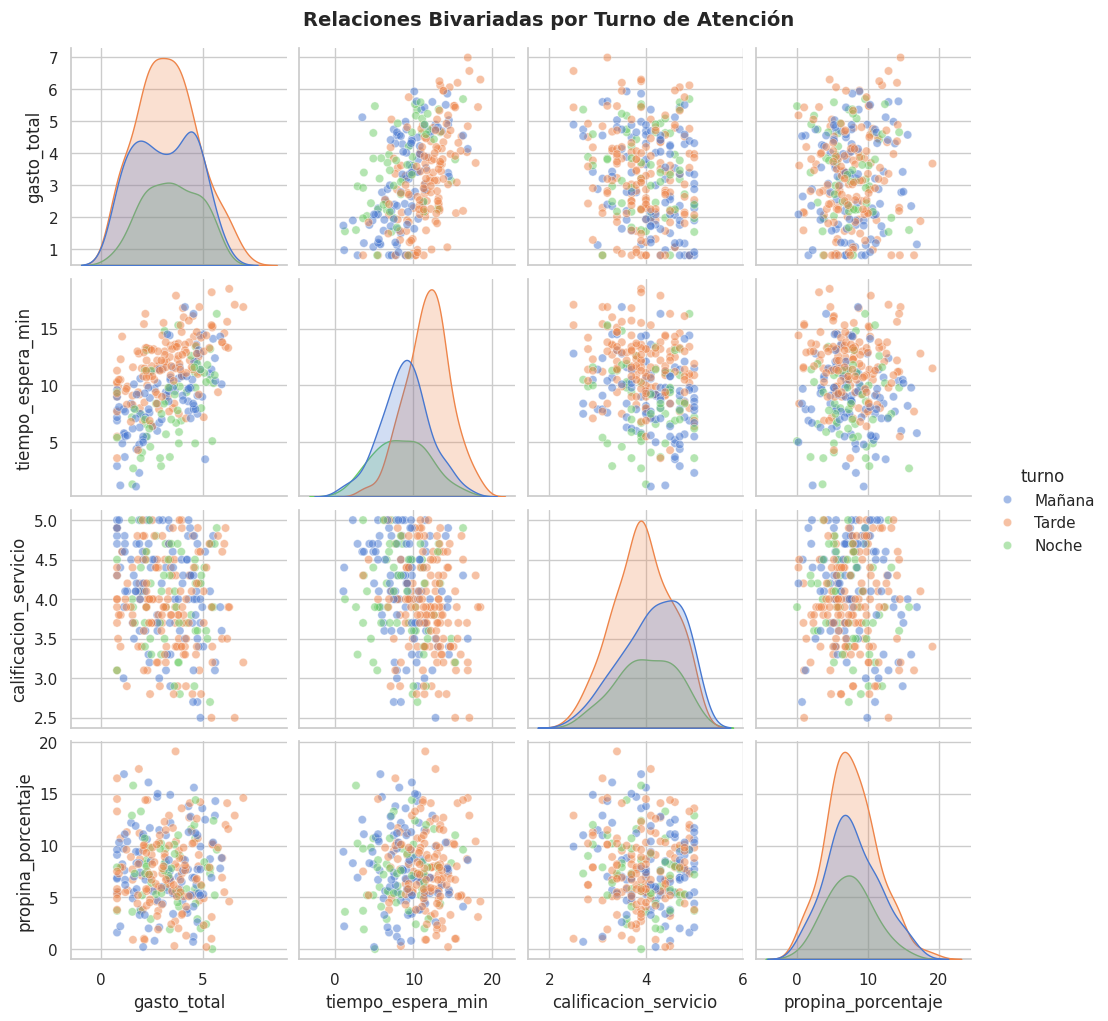

In [26]:

vars_plot = ['gasto_total', 'tiempo_espera_min', 'calificacion_servicio', 'propina_porcentaje']
g = sns.pairplot(
    df[vars_plot + ['turno']],
    hue='turno',
    hue_order=['Mañana', 'Tarde', 'Noche'],
    diag_kind='kde',
    plot_kws={'alpha': 0.5},
    palette='muted'
)

g.figure.suptitle(
    'Relaciones Bivariadas por Turno de Atención',
    y=1.02, fontsize=14, fontweight='bold'
)

g.savefig('desafio_pairplot.svg', bbox_inches='tight')
g.savefig('desafio_pairplot.pdf', bbox_inches='tight')
g.savefig('desafio_pairplot.png', dpi=300, bbox_inches='tight')

plt.show()